In [28]:
!pip install clean-fid
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.7 MB/s eta 0:00:00


In [3]:
!git clone https://github.com/pakhomovee/REPA-diffusion.git

Cloning into 'REPA-diffusion'...
remote: Enumerating objects: 182, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 182 (delta 45), reused 28 (delta 10), pack-reused 98 (from 1)
Receiving objects: 100% (182/182), 21.46 MiB | 20.04 MiB/s, done.
Resolving deltas: 100% (67/67), done.


In [10]:
%cd REPA-diffusion

[Errno 2] No such file or directory: 'REPA-diffusion'
/content/REPA-diffusion


In [11]:
!git submodule update --init --recursive

Submodule 'REPA' (https://github.com/sekopylov/REPA.git) registered for path 'REPA'
Cloning into '/content/REPA-diffusion/REPA'...
Submodule path 'REPA': checked out '77349d30e8b2e94a6c733dd3f8daf254f0c135f8'


In [ ]:
!git submodule update --remote

# Загрузка и распаковка .zip со всеми чекпоинтами

In [6]:
from scripts.utils.utils import download_and_extract
download_and_extract("https://disk.yandex.ru/d/cVqGejaNA3ZUXA", "baseline")
download_and_extract("https://disk.yandex.ru/d/CtAR61Rz3sZ60w", "repa")

Downloading...


data.zip: 100%|██████████| 7.14G/7.14G [09:06<00:00, 14.0MB/s]


Extracting...


Extracting: 100%|██████████| 18/18 [00:57<00:00,  3.18s/file]


Done.
Downloading...


data.zip: 100%|██████████| 15.1G/15.1G [18:15<00:00, 14.8MB/s]


Extracting...


Extracting: 100%|██████████| 22/22 [02:00<00:00,  5.47s/file]


Done.


# Загрузка 3х главных чекпоинтов

In [ ]:
from scripts.utils.utils import download
download("https://disk.yandex.ru/d/8s9Qx7_HwDZDag", "0040000_baseline.pt")
download("https://disk.yandex.ru/d/a9LMmSuYQhhlRQ", "0040000_repa.pt")
download("https://disk.yandex.ru/d/YqzNy5x6Q-Wdfw", "0080000_repa.pt")

# Загрузка датасета

In [25]:
!chmod +x scripts/export_celeba_for_repa.py
!./scripts/export_celeba_for_repa.py

Downloading...
From (original): https://drive.google.com/uc?id=1zVyBr0Q667RK_0j6QANLAajNQxp3yWOl
From (redirected): https://drive.google.com/uc?id=1zVyBr0Q667RK_0j6QANLAajNQxp3yWOl&confirm=t&uuid=3cb6b7be-08a9-4c02-a91a-659b2dd18c16
To: /content/REPA-diffusion/data/celeba/img_align_celeba.zip
100% 1.49G/1.49G [00:46<00:00, 32.4MB/s]
Extracting /content/REPA-diffusion/data/celeba/img_align_celeba.zip...
Extraction finished.
Retrieving folder contents
Processing file 1ErGMvfVvkx_f6MLu6OkFxZVYcVrRdo7C identity_CelebA.txt
Processing file 17yW3RK1ofFedo86g70v42lJx4WaTYYI6 list_attr_celeba.txt
Processing file 1c64jrUjTPMuv4Cqmf58CmpNTTXB_v5IA list_bbox_celeba.txt
Processing file 1kD-DpI-a0Oi7DFL_bsOc9MUvXV2eqfyV list_landmarks_align_celeba.txt
Processing file 1WIIpwASq0Ki3ZyLSExomwSFje37dIXWw list_landmarks_celeba.txt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1ErGMvfVvkx_f6MLu6O

# [!!! IMPORTANT] см. изменение ниже

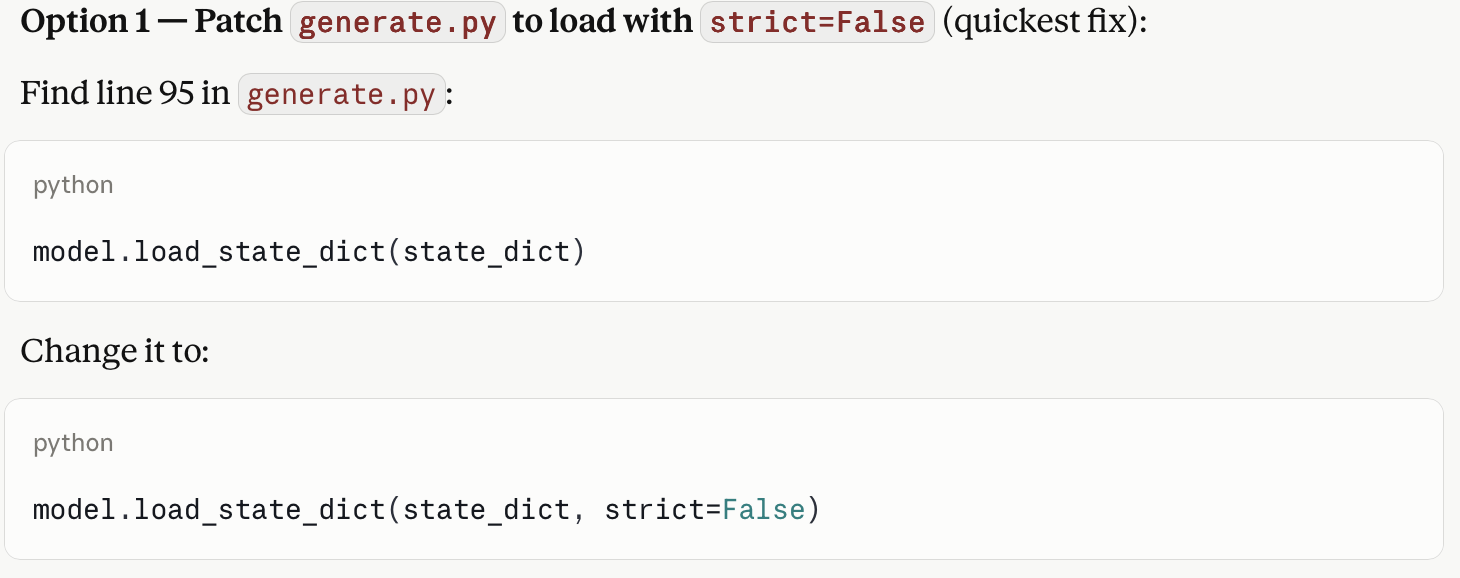

## Вот так выглядят команды для генерации

In [ ]:
!torchrun --nnodes=1 --nproc_per_node=1 REPA/generate.py \
  --model SiT-B/2 \
  --num-classes 16 \
  --num-fid-samples 100 \
  --ckpt /content/REPA-diffusion/baseline/celeba_sit_b2_baseline_gpus2-7_40k/checkpoints/0040000.pt \
  --path-type=linear \
  --encoder-depth=4 \
  --projector-embed-dims=768 \
  --per-proc-batch-size=128 \
  --mode=sde \
  --num-steps=250 \
  --cfg-scale=1.8 \
  --guidance-high=0.7

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Starting rank=0, seed=0, world_size=1.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
config.json: 100% 547/547 [00:00<00:00, 2.14MB/s]
diffusion_pytorch_model.safetensors: 100% 335M/335M [00:03<00:00, 92.1MB/s]
Saving .png samples at samples/SiT-B-2-0040000-size-256-vae-ema-cfg-1.8-seed-0-sde
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group`

In [6]:
!torchrun --nnodes=1 --nproc_per_node=1 REPA/generate.py \
  --model SiT-B/2 \
  --num-classes 16 \
  --num-fid-samples 100 \
  --ckpt /content/REPA-diffusion/repa/celeba_sit_b2_repa_dinov2b_gpus4-7/checkpoints/0040000.pt \
  --path-type=linear \
  --encoder-depth=4 \
  --projector-embed-dims=768 \
  --per-proc-batch-size=128 \
  --mode=sde \
  --num-steps=250 \
  --cfg-scale=1.8 \
  --guidance-high=0.7

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Starting rank=0, seed=0, world_size=1.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Saving .png samples at samples/SiT-B-2-0040000-size-256-vae-ema-cfg-1.8-seed-0-sde
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)
[rank0]:[W515 09:13:07.004258029 ProcessGroupNCCL.cpp:5138] Guessing dev

# Подсчет метрик и построение графиков

In [18]:
import os
import subprocess
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path


# ── 1. GENERATION ─────────────────────────────────────────────────────────────
def generate_samples(
    ckpt_path: str,
    output_dir: str,
    model: str = "SiT-B/2",
    num_classes: int = 16,
    num_fid_samples: int = 1000,
    per_proc_batch_size: int = 64,
    encoder_depth: int = 4,
    projector_embed_dims: int = 768,
    path_type: str = "linear",
    mode: str = "sde",
    num_steps: int = 250,
    cfg_scale: float = 1.8,
    guidance_high: float = 0.7,
    repa_root: str = "/content/REPA-diffusion/REPA",
    device_count: int = 1,
) -> str:
    """
    Run generate.py for a single checkpoint and return the path to the
    produced .npz file.

    generate.py always writes to {repa_root}/samples/<name>.npz.
    We clean that folder before each run to avoid picking up a stale
    file from a previous run, then move the result to output_dir.
    """
    os.makedirs(output_dir, exist_ok=True)
    samples_dir = Path(repa_root) / "samples"
    samples_dir.mkdir(exist_ok=True)

    # Remove any leftover .npz so we can't accidentally grab a stale one
    for old in samples_dir.glob("*.npz"):
        old.unlink()
        print(f"Removed stale: {old.name}")

    cmd = [
        "torchrun",
        "--nnodes=1",
        f"--nproc_per_node={device_count}",
        f"{repa_root}/generate.py",
        f"--model={model}",
        f"--num-classes={num_classes}",
        f"--num-fid-samples={num_fid_samples}",
        f"--ckpt={ckpt_path}",
        f"--path-type={path_type}",
        f"--encoder-depth={encoder_depth}",
        f"--projector-embed-dims={projector_embed_dims}",
        f"--per-proc-batch-size={per_proc_batch_size}",
        f"--mode={mode}",
        f"--num-steps={num_steps}",
        f"--cfg-scale={cfg_scale}",
        f"--guidance-high={guidance_high}",
    ]

    print(f"\n{'='*60}")
    print(f"Generating: {Path(ckpt_path).name}")
    print(f"{'='*60}")
    print("CMD:", " ".join(cmd))

    subprocess.run(cmd, cwd=repa_root, check=True)

    npz_files = sorted(samples_dir.glob("*.npz"), key=os.path.getmtime, reverse=True)
    assert npz_files, f"No .npz found in {samples_dir} after generation."

    npz_src = npz_files[0]
    npz_dst = Path(output_dir) / npz_src.name
    npz_src.rename(npz_dst)
    print(f"Saved: {npz_dst}")
    return str(npz_dst)

def generate_all_checkpoints(
    checkpoints: dict[str, list[str]],
    samples_root: str = "/content/REPA-diffusion/samples",
    **generate_kwargs,
) -> dict[str, list[str]]:
    npz_paths: dict[str, list[str]] = {}

    for run_name, ckpt_list in checkpoints.items():
        npz_paths[run_name] = []

        for ckpt_path in ckpt_list:
            step = Path(ckpt_path).stem
            out_dir = os.path.join(samples_root, run_name, f"step_{step}")

            # Check if an .npz already exists in this output dir
            existing = list(Path(out_dir).glob("*.npz")) if Path(out_dir).exists() else []
            if existing:
                print(f"Skipping {run_name} @ {step} — found existing: {existing[0].name}")
                npz_paths[run_name].append(str(existing[0]))
                continue

            npz = generate_samples(ckpt_path, out_dir, **generate_kwargs)
            npz_paths[run_name].append(npz)

    return npz_paths

In [ ]:
from cleanfid import fid as cleanfid

def compute_fid_kid(
    npz_paths: dict[str, list[str]],
    real_data_dir: str,
    checkpoint_steps: list[int],
) -> tuple[dict[str, list[float]], dict[str, list[float]]]:

    def npz_to_png_dir(npz_path: str) -> str:
        """Extract .npz images to a sibling /images/ folder, skip if already done."""
        img_dir = str(Path(npz_path).parent / "images")
        if Path(img_dir).exists() and any(Path(img_dir).glob("*.png")):
            print(f"  Reusing existing images: {img_dir}")
            return img_dir
        os.makedirs(img_dir, exist_ok=True)
        samples = np.load(npz_path)["arr_0"]  # (N, H, W, C) uint8
        print(f"  Extracting {len(samples)} images to {img_dir} ...")
        for i, img in enumerate(samples):
            Image.fromarray(img).save(os.path.join(img_dir, f"{i:06d}.png"))
        return img_dir

    fid_scores: dict[str, list[float]] = {}
    kid_scores: dict[str, list[float]] = {}

    for run_name, paths in npz_paths.items():
        fid_scores[run_name] = []
        kid_scores[run_name] = []

        for step, npz_path in zip(checkpoint_steps, paths):
            print(f"\nScoring {run_name} @ step {step} ...")
            img_dir = npz_to_png_dir(npz_path)

            fid_val = cleanfid.compute_fid(
                fdir1=img_dir,
                fdir2=real_data_dir,
                mode="clean",
            )
            kid_val = cleanfid.compute_kid(
                fdir1=img_dir,
                fdir2=real_data_dir,
                mode="clean",
            )

            fid_scores[run_name].append(fid_val)
            kid_scores[run_name].append(kid_val)
            print(f"  FID: {fid_val:.2f}  KID: {kid_val:.5f}")

    return fid_scores, kid_scores

def plot_fid(
    checkpoint_steps: list[int],
    fid_scores: dict[str, list[float]],
    output_path: str = "fid_plot.png",
    title: str = "FID vs Training Steps",
):
    fig, ax = plt.subplots(figsize=(8, 5))
    for run_name, scores in fid_scores.items():
        ax.plot(checkpoint_steps, scores, marker="o", label=run_name)
    ax.set_xlabel("Training Steps")
    ax.set_ylabel("FID ↓")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.close(fig)
    print(f"FID plot saved: {output_path}")


def plot_kid(
    checkpoint_steps: list[int],
    kid_scores: dict[str, list[float]],
    output_path: str = "kid_plot.png",
    title: str = "KID vs Training Steps",
):
    fig, ax = plt.subplots(figsize=(8, 5))
    for run_name, scores in kid_scores.items():
        scaled = [s * 1e3 for s in scores]
        ax.plot(checkpoint_steps, scaled, marker="o", label=run_name)
    ax.set_xlabel("Training Steps")
    ax.set_ylabel("KID × 10³ ↓")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.close(fig)
    print(f"KID plot saved: {output_path}")

In [26]:
from pathlib import Path

ROOT       = Path("/content/REPA-diffusion")
STEPS      = [10000, 20000, 30000, 40000]
STEP_STRS  = [f"{s:07d}" for s in STEPS]

# ── point at your checkpoint dirs ────────────────────────────────────────
checkpoints = {
    "Baseline": [
        ROOT / "baseline/celeba_sit_b2_baseline_gpus2-7_40k/checkpoints" / f"{s}.pt"
        for s in STEP_STRS
    ],
    "REPA (DINOv2-B)": [
        ROOT / "repa/celeba_sit_b2_repa_dinov2b_gpus4-7/checkpoints" / f"{s}.pt"
        for s in STEP_STRS
    ],
}
checkpoints = {k: [str(p) for p in v] for k, v in checkpoints.items()}

npz_paths = generate_all_checkpoints(
    checkpoints=checkpoints,
    samples_root=str(ROOT / "samples"),
    num_fid_samples=100,
    per_proc_batch_size=64,
)

fid_scores, kid_scores = compute_fid_kid(
    npz_paths=npz_paths,
    real_data_dir=str(ROOT / "data/celeba256/images"),
    checkpoint_steps=STEPS,
)
plot_fid(STEPS, fid_scores, output_path=str(ROOT / "fid_plot.png"))
plot_kid(STEPS, kid_scores, output_path=str(ROOT / "kid_plot.png"))

Skipping Baseline @ 0010000 — found existing: SiT-B-2-0010000-size-256-vae-ema-cfg-1.8-seed-0-sde.npz
Skipping Baseline @ 0020000 — found existing: SiT-B-2-0020000-size-256-vae-ema-cfg-1.8-seed-0-sde.npz
Skipping Baseline @ 0030000 — found existing: SiT-B-2-0030000-size-256-vae-ema-cfg-1.8-seed-0-sde.npz
Skipping Baseline @ 0040000 — found existing: SiT-B-2-0040000-size-256-vae-ema-cfg-1.8-seed-0-sde.npz
Skipping REPA (DINOv2-B) @ 0010000 — found existing: SiT-B-2-0010000-size-256-vae-ema-cfg-1.8-seed-0-sde.npz
Skipping REPA (DINOv2-B) @ 0020000 — found existing: SiT-B-2-0020000-size-256-vae-ema-cfg-1.8-seed-0-sde.npz
Skipping REPA (DINOv2-B) @ 0030000 — found existing: SiT-B-2-0030000-size-256-vae-ema-cfg-1.8-seed-0-sde.npz
Skipping REPA (DINOv2-B) @ 0040000 — found existing: SiT-B-2-0040000-size-256-vae-ema-cfg-1.8-seed-0-sde.npz

Scoring Baseline @ step 10000 ...
  Reusing existing images: /content/REPA-diffusion/samples/Baseline/step_0010000/images
compute FID between two folders
F

FID images : 100%|██████████| 4/4 [00:04<00:00,  1.06s/it]


Found 202599 images in the folder /content/REPA-diffusion/data/celeba256/images


FID images : 100%|██████████| 6332/6332 [03:52<00:00, 27.22it/s]


compute KID between two folders
Found 100 images in the folder /content/REPA-diffusion/samples/Baseline/step_0010000/images


...

compute KID between two folders
Found 100 images in the folder /content/REPA-diffusion/samples/REPA (DINOv2-B)/step_0040000/images


KID images : 100%|██████████| 4/4 [00:05<00:00,  1.25s/it]


Found 202599 images in the folder /content/REPA-diffusion/data/celeba256/images


KID images : 100%|██████████| 6332/6332 [03:59<00:00, 26.43it/s]


  FID: 85.12  KID: 0.01594
FID plot saved: /content/REPA-diffusion/fid_plot.png
KID plot saved: /content/REPA-diffusion/kid_plot.png


In [29]:
import lpips
from torchvision import transforms

def compute_lpips_from_npz(
    npz_a: str,
    npz_b: str,
    label_a: str = "baseline",
    label_b: str = "repa",
    batch_size: int = 32,
    image_size: int = 256,
    net: str = "alex",
    device: str | None = None,
    max_samples: int | None = None,
) -> dict[str, float]:
    """
    Compute LPIPS between two sets of generated images stored as .npz files.
    Since you have no real images, this compares baseline-generated vs
    REPA-generated to quantify perceptual diversity / difference between
    the two models.

    Both .npz files must contain an 'arr_0' key with shape (N, H, W, C),
    uint8, values in [0, 255] — the format produce.py writes.

    Args:
        npz_a:       Path to first .npz  (e.g. baseline final checkpoint).
        npz_b:       Path to second .npz (e.g. REPA final checkpoint).
        label_a/b:   Names used in the printed summary.
        batch_size:  Pairs per forward pass (reduce if OOM).
        image_size:  Resize to this before scoring.
        net:         LPIPS backbone: "alex" | "vgg" | "squeeze".
        device:      "cuda" / "cpu" / None (auto).
        max_samples: Cap number of pairs (both npz are truncated to this).

    Returns:
        {"mean": float, "std": float, "n": int}

    Example:
        result = compute_lpips_from_npz(
            npz_a="samples/baseline/step_0040000/samples.npz",
            npz_b="samples/repa/step_0040000/samples.npz",
        )
        print(f"LPIPS: {result['mean']:.4f} ± {result['std']:.4f}")
    """

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    loss_fn = lpips.LPIPS(net=net).to(device)
    loss_fn.eval()

    images_a = np.load(npz_a)["arr_0"]   # (N, H, W, C) uint8
    images_b = np.load(npz_b)["arr_0"]

    n = min(len(images_a), len(images_b))
    if max_samples is not None:
        n = min(n, max_samples)
    images_a = images_a[:n]
    images_b = images_b[:n]
    print(f"Scoring LPIPS: {label_a} vs {label_b}  ({n} pairs)")

    preprocess = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # → [-1, 1]
    ])

    scores = []
    for i in range(0, n, batch_size):
        batch_a = torch.stack([preprocess(img) for img in images_a[i:i+batch_size]]).to(device)
        batch_b = torch.stack([preprocess(img) for img in images_b[i:i+batch_size]]).to(device)

        with torch.no_grad():
            batch_scores = loss_fn(batch_a, batch_b).squeeze().cpu()
        scores.extend(batch_scores.tolist() if batch_scores.dim() > 0 else [batch_scores.item()])
        print(f"  {i + len(batch_a)}/{n} pairs scored...")

    scores = np.array(scores)
    result = {"mean": float(scores.mean()), "std": float(scores.std()), "n": int(n)}
    print(f"\nLPIPS ({net})  {label_a} vs {label_b}: "
          f"{result['mean']:.4f} ± {result['std']:.4f}  (n={result['n']})")
    return result

In [30]:
compute_lpips_from_npz(
    npz_a=npz_paths["Baseline"][-1],
    npz_b=npz_paths["REPA (DINOv2-B)"][-1],
    label_a="Baseline",
    label_b="REPA (DINOv2-B)",
)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 234MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Scoring LPIPS: Baseline vs REPA (DINOv2-B)  (100 pairs)
  32/100 pairs scored...
  64/100 pairs scored...
  96/100 pairs scored...
  100/100 pairs scored...

LPIPS (alex)  Baseline vs REPA (DINOv2-B): 0.0839 ± 0.0619  (n=100)


{'mean': 0.08394300997257233, 'std': 0.061895920549826254, 'n': 100}